In [5]:
import snappy
import khovanov
import networkx as nx
from knot_graphs import *

## Approach: do band moves entirely within kh package
### ~TODO - write `writhe` function for `khovanov.Link`~
### TODO - write `normal_euler_number` function for `khovanov.Cobordism`

In [60]:
L = khovanov.Link(snappy.Link('L4a1').PD_code())
K = khovanov.Link(snappy.Link('4_1').PD_code())
print(vars(L))
print(vars(K))

{'crossings': [0, 1, 2, 3]}
{'crossings': [0, 1, 2, 3]}


In [66]:
def writhe(link : khovanov.Link):
    link.orient()
    n_plus, n_minus = link.get_signs()
    return n_plus - n_minus

In [67]:
def normal_euler_number(cob : khovanov.Cobordism):
    knot = cob.links[0]
    knot_prime = cob.links[-1]

    writhe1 = writhe(knot)
    writhe2 = writhe(knot_prime)
    print(f'{writhe1} {writhe2}')
    return writhe2 - writhe1

In [68]:
K = snappy.Link('3_1')
K_kh = khovanov.Link(K.PD_code())

['arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15']
{(0, 1, 0): -0.15, (0, 1, 1): 0.15, (1, 2, 0): -0.15, (1, 2, 1): 0.15, (2, 0, 0): -0.15, (2, 0, 1): 0.15}


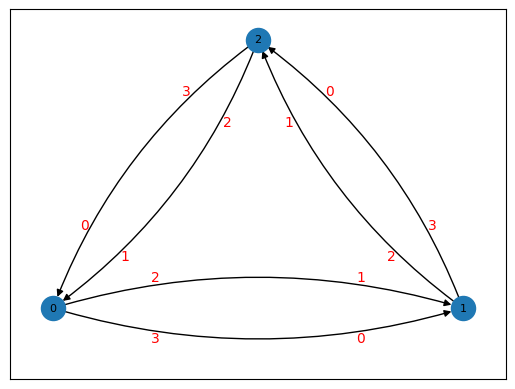

In [72]:
draw_adjacency_graph(K)

In [69]:
K

<Link 3_1: 1 comp; 3 cross>

In [70]:
K_kh

Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (0, 0)]

In [74]:
cob = khovanov.Cobordism(K_kh)
cob.band_move(-1, (0,0), (2,3))
print(normal_euler_number(cob))

-3 -2
1


## ~Approach - write band move function from scratch~

### Bands are described by paths in the dual graph with additional data about over/under crossings at strand intersections

### TODO - draw dual graph on top of adjacency crossing graph

#### the goal here is to draw the dual graph over top of the knot diagram itself

In [8]:
K = snappy.Link('4_1')
dg = K.dual_graph()

In [12]:
vars(dg)

{'vertices': {<F0>, <F1>, <F2>, <F3>, <F4>, <F5>},
 'edges': {<F0> --- <F1>,
  <F0> --- <F3>,
  <F0> --- <F4>,
  <F1> --- <F2>,
  <F2> --- <F3>,
  <F2> --- <F4>,
  <F3> --- <F5>,
  <F4> --- <F5>},
 'incidence_dict': {<F0>: [<F0> --- <F1>, <F0> --- <F3>, <F0> --- <F4>],
  <F1>: [<F0> --- <F1>, <F1> --- <F2>],
  <F3>: [<F0> --- <F3>, <F2> --- <F3>, <F3> --- <F5>],
  <F4>: [<F0> --- <F4>, <F2> --- <F4>, <F4> --- <F5>],
  <F2>: [<F1> --- <F2>, <F2> --- <F3>, <F2> --- <F4>],
  <F5>: [<F3> --- <F5>, <F4> --- <F5>]},
 'Edge': spherogram.graphs.Edge,
 'edge_to_face': {<CS 3, 3>: <F0>,
  <CS 0, 3>: <F0>,
  <CS 2, 1>: <F0>,
  <CS 3, 2>: <F1>,
  <CS 2, 2>: <F1>,
  <CS 3, 1>: <F2>,
  <CS 2, 3>: <F2>,
  <CS 1, 3>: <F2>,
  <CS 3, 0>: <F3>,
  <CS 1, 0>: <F3>,
  <CS 0, 2>: <F3>,
  <CS 2, 0>: <F4>,
  <CS 0, 0>: <F4>,
  <CS 1, 2>: <F4>,
  <CS 1, 1>: <F5>,
  <CS 0, 1>: <F5>}}

In [14]:
dg_nx = dg.to_networkx()

In [22]:
dg_nx.nodes.data()

NodeDataView({<F2>: {}, <F5>: {}, <F1>: {}, <F4>: {}, <F3>: {}, <F0>: {}})

In [25]:
dg_nx.edges

MultiEdgeView([(<F2>, <F3>, 0), (<F2>, <F1>, 0), (<F2>, <F4>, 0), (<F5>, <F3>, 0), (<F5>, <F4>, 0), (<F1>, <F0>, 0), (<F4>, <F0>, 0), (<F3>, <F0>, 0)])

In [28]:
def draw_dual_graph(knot):
    dg = knot.dual_graph().to_networkx()
    layout = nx.spring_layout(dg)
    nx.draw_networkx(dg, pos=layout)
    #nx.draw_networkx_labels(dg, pos=layout, font_size=10)

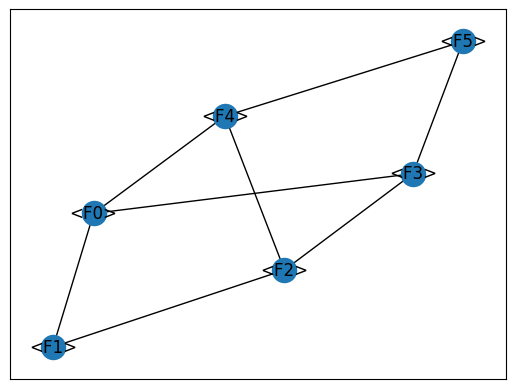

In [29]:
draw_dual_graph(K)

['arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0', 'arc3,rad=-0.15', 'arc3,rad=0']
{(0, 1, 0): -0.15, (0, 3, 0): 0, (1, 0, 0): -0.15, (1, 2, 0): 0, (2, 3, 0): -0.15, (2, 0, 0): 0, (3, 2, 0): -0.15, (3, 1, 0): 0}


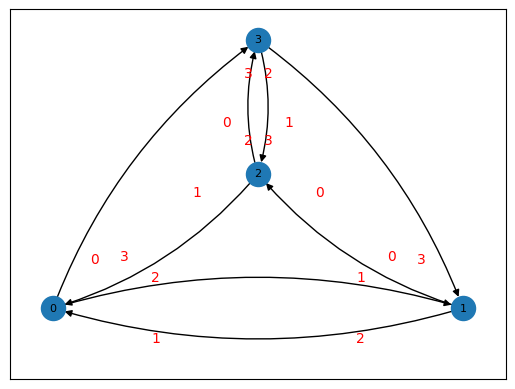

In [31]:
draw_adjacency_graph(K)